In [1]:
from datetime import datetime

print(f"Timestamp: {datetime.now()}")

Timestamp: 2025-12-09 12:18:42.525163


# Gaussian fit

**Pinned Environment:** [`envs/sc-scvi.yaml`](../.../envs/sc-scvi.yaml)  

In [2]:
from pathlib import Path
import os
import scanpy as sc
import pandas as pd
import numpy as np
import anndata as ad
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
from sklearn.mixture import GaussianMixture
import seaborn as sns
from scipy import sparse
import warnings
import session_info
import sys

In [3]:
#plt.rcParams['figure.figsize'] = (3, 3)
#plt.rcParams['figure.dpi'] = 150
#warnings.simplefilter(action='ignore', category=FutureWarning)

### Setup

In [4]:
sys.path.append(str(Path.cwd().resolve().parents[1]))

from config.paths import BASE_DIR

input_dir = BASE_DIR / "data/h5ad/export_03/03b_seurat"

In [5]:
base_dir = Path("/home/workspace/projects/drg")
adata_path = base_dir / "data/h5ad/export_03/03b_seurat/adata-merged-labels.h5ad"
adata_ref_path = base_dir / "data/h5ad/export_02/02b_leiden/adata-leiden-480.h5ad"

output_dir = base_dir / "data/h5ad/export_03/03c_thresholds"
output_dir.mkdir(parents=True, exist_ok=True)

### Read and process adata

In [6]:
adata_ref = sc.read_h5ad(adata_ref_path)
adata = sc.read_h5ad(adata_path)

In [7]:
adata_list = [adata, adata_ref]

for ad in adata_list:
    ad.var_names = ad.var_names.where(
        ad.var_names != "tdTomato_Seq2",
        "dTomato_Seq2"
    )

In [8]:
adata.X[:5, :5].toarray()

array([[0.        , 0.07718503, 0.        , 0.        , 0.        ],
       [0.15104409, 0.        , 0.7026269 , 0.81696594, 0.        ],
       [0.14967822, 0.        , 0.3390768 , 0.9915224 , 0.        ],
       [0.        , 0.        , 0.        , 1.369404  , 0.        ],
       [0.        , 0.5700411 , 0.        , 0.5700411 , 0.        ]],
      dtype=float32)

In [9]:
adata.X = adata.layers['counts'].copy()
adata_ref.X = adata_ref.layers['counts'].copy()

In [10]:
genes = ['EGFP_Seq1', 'dTomato_Seq2']

In [11]:
def to_dense(x):
    return x.toarray().ravel() if hasattr(x, "toarray") else np.ravel(x)

# Raw counts for filtering
egfp_raw_all = to_dense(adata_ref[:, "EGFP_Seq1"].X)
td_raw_all   = to_dense(adata_ref[:, "dTomato_Seq2"].X)

# Filter to include only cells with >1 raw count in both genes
bg_filter = (egfp_raw_all > 1) & (td_raw_all > 1)

gauss_results = {}

# Fit a Gaussian distribution to filtered signal
for g in genes:
    x_raw_full = to_dense(adata_ref[:, g].X)
    x_raw = x_raw_full[bg_filter]

    # log1p transform
    x_log = np.log1p(x_raw)

    # Fit Gaussian
    mu = np.mean(x_log)
    sigma = np.std(x_log)

    # 99th percentile of Gaussian = mean + 2.326 * sd
    thr_log = mu + 2.326 * sigma

    # call positives
    hi_mask = np.zeros(adata_ref.n_obs, dtype=bool)
    hi_mask[bg_filter] = x_log > thr_log
    adata_ref.obs[f"{g}_hi"] = hi_mask

    gauss_results[g] = {
        "x_log": x_log,
        "thr_log": thr_log,
        "mu": mu,
        "sigma": sigma
    }

In [12]:
# Dual-high
adata_ref.obs['EGFP_dTomato_dual_hi'] = (
    adata_ref.obs['EGFP_Seq1_hi'] &
    adata_ref.obs['dTomato_Seq2_hi']
)

dual = adata_ref.obs['EGFP_dTomato_dual_hi'][bg_filter].values

# Extract for plotting
x_egfp_log = gauss_results["EGFP_Seq1"]["x_log"]
x_td_log   = gauss_results["dTomato_Seq2"]["x_log"]
thr_egfp_log = gauss_results["EGFP_Seq1"]["thr_log"]
thr_td_log   = gauss_results["dTomato_Seq2"]["thr_log"]

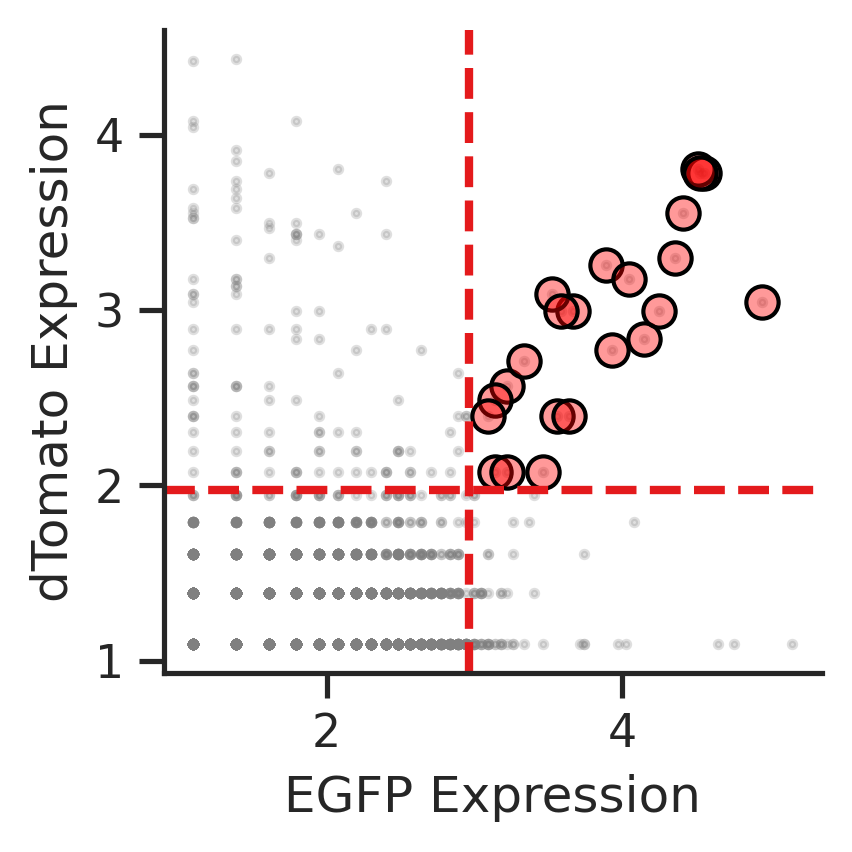

In [13]:
# Plot
sns.set_theme(style="ticks")

plt.figure(figsize=(3,3), dpi=300)
ax = plt.gca()

ax.scatter(x_egfp_log, x_td_log, s=3, color="gray", alpha=0.25)
ax.scatter(x_egfp_log[dual], x_td_log[dual],
           s=60, facecolors=(1,0,0,0.4), edgecolors="black")

ax.axvline(thr_egfp_log, color="#e41a1c", ls="--", lw=2)
ax.axhline(thr_td_log,   color="#e41a1c", ls="--", lw=2)

ax.set_xlabel("EGFP Expression")
ax.set_ylabel("dTomato Expression")
ax.set_title("")

sns.despine()
plt.tight_layout()
plt.show()

In [14]:
# Column-wise copy from ref_data to adata
adata.obs[["EGFP_Seq1_hi", "dTomato_Seq2_hi", "EGFP_dTomato_dual_hi"]] = \
    adata_ref.obs[["EGFP_Seq1_hi", "dTomato_Seq2_hi", "EGFP_dTomato_dual_hi"]].values

In [15]:
for ad in adata_list:
    mask = ad.obs["EGFP_dTomato_dual_hi"].fillna(False)
    dual_barcodes = ad.obs.index[mask].tolist()

    print("\nDual-positive barcodes:")
    for bc in dual_barcodes:
        print(bc)
    print(f"\nTotal: {len(dual_barcodes)} barcodes printed.")


Dual-positive barcodes:
apeeemip-1
bpoikicj-1
cbhmmeof-1
bmjgagok-1
ijnggkoc-1
llknggjo-1
llmfnafp-1
llmgffik-1
jjmnhibg-1
jkabbhfm-1
aefmnmje-1
mklknhcg-1
ajnphbmj-1
eckajpnf-1
akcoadof-1
bgmdeeeb-1
hjjgalia-1
hjjkhdhk-1
mnhcfodp-1
aapmhgin-1
ebnbhhob-1
ebnfggjb-1
ikjbpmlk-1

Total: 23 barcodes printed.

Dual-positive barcodes:
apeeemip-1-0
bpoikicj-1-0
cbhmmeof-1-0
bmjgagok-1-1
ijnggkoc-1-1
llknggjo-1-1
llmfnafp-1-1
llmgffik-1-1
jjmnhibg-1-2
jkabbhfm-1-2
aefmnmje-1-3
mklknhcg-1-3
ajnphbmj-1-6
eckajpnf-1-6
akcoadof-1-7
bgmdeeeb-1-7
hjjgalia-1-7
hjjkhdhk-1-7
mnhcfodp-1-7
aapmhgin-1-9
ebnbhhob-1-10
ebnfggjb-1-10
ikjbpmlk-1-10

Total: 23 barcodes printed.


# Export

In [16]:
filename = os.path.join(output_dir, 'adata-labeled.h5ad')
os.makedirs(os.path.dirname(filename), exist_ok = True)

adata.write_h5ad(filename, compression='gzip')